In [1]:
#set the environment variable for Groq API key
import os

# The GROQ_API_KEY should be set as an environment variable
# In your terminal, run: set GROQ_API_KEY=your_actual_key_here
# This way the key is not stored in the code

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [2]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)
response = llm.invoke("What is the capital of France?").content
print(response)


The capital of France is Paris.


Define a Graph

Define Schema Graph

In [3]:
from typing import TypedDict,List

class SchemaGraph(TypedDict):
    name: str
    message: str

Create the Node function

In [4]:
def welcome(state:SchemaGraph) -> SchemaGraph:
    current_name = state["name"]
    current_message = state["message"]

    response = llm.invoke(f"my name is {current_name} and my message is {current_message}. Please respond with a new message.").content
    state["message"] = f"Your message was:{current_message}.Here is my reponse: {response}"
    return state


CREATE THE STATE GRAPH

In [6]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(SchemaGraph)
#add the node
graph.add_node("welcome",welcome)

#add edges
graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)


COMPILE THE GRAPH

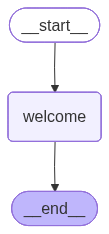

In [10]:
from IPython.display import Image,display

first_graph = graph.compile()
Image(first_graph.get_graph().draw_mermaid_png())

RUN THE GRAPH

In [11]:
first_graph.invoke({"name":"Sandip","message":"Hello,How are you?"})

{'name': 'Sandip',
 'message': "Your message was:Hello,How are you?.Here is my reponse: Hello Sandip, I'm doing well, thanks for asking. How about you, how's your day going?"}